# Customer Churn Prediction
**Goal:** Predict which customers will leave the telecom company using Machine Learning.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve,
    classification_report,
    ConfusionMatrixDisplay
)


# Load & Explore Data (EDA)

In [2]:
# Read the dataset; keep main_df as backup, work on df
main_df=pd.read_csv('.\\telco_churn.csv')
df=main_df.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Get the list of column names to review
cols=df.columns.to_list()
cols

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
# Standardize column names for consistency
changed_col_names={
 'gender':'Gender',
 'tenure':'Tenure'
}

df=df.rename(columns=changed_col_names)

In [5]:
# Group ID-like and target columns separately for easy reference
id_like_cols=['customerID']
target_cols=['Churn']

In [6]:
# Drop ID-like columns because they are not useful for modelling
df=df.drop(id_like_cols, axis=1)

In [7]:
# Display summary info: columns, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
# Check if null values exist as a first step to handle them later
nulls_check=df.isnull().sum()
print(nulls_check)
print(f'\nTotal count of nulls: {df.isnull().sum().sum()}')

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total count of nulls: 0


In [9]:
# Statistical information
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Check constant features
constant=[]
for i in df.columns.to_list():
    if df[i].nunique()==1:
        constant.append(i)
print(f'Number of constant features: {len(constant)}')

Number of constant features: 0


In [11]:
'''
Inspect unique values in numerical columns to detect anomalies,
Identify mistyped categoricals,
Understand whether columns are continuous or discrete
'''
num_cols=df.select_dtypes(exclude='object').columns.to_list()
for col in num_cols:
    print(f'Column: {col}\n{df[col].nunique()} unique values: {df[col].unique()}')

Column: SeniorCitizen
2 unique values: [0 1]
Column: Tenure
73 unique values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Column: MonthlyCharges
1585 unique values: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]


In [12]:
# Identify mistyped numericals
# Check for possible typos or inconsistent labels
cat_cols=df.select_dtypes(include='object').columns.to_list()
for col in cat_cols:
    print(f'Column: {col}\n{df[col].nunique()} unique values: {df[col].unique()}')

Column: Gender
2 unique values: ['Female' 'Male']
Column: Partner
2 unique values: ['Yes' 'No']
Column: Dependents
2 unique values: ['No' 'Yes']
Column: PhoneService
2 unique values: ['No' 'Yes']
Column: MultipleLines
3 unique values: ['No phone service' 'No' 'Yes']
Column: InternetService
3 unique values: ['DSL' 'Fiber optic' 'No']
Column: OnlineSecurity
3 unique values: ['No' 'Yes' 'No internet service']
Column: OnlineBackup
3 unique values: ['Yes' 'No' 'No internet service']
Column: DeviceProtection
3 unique values: ['No' 'Yes' 'No internet service']
Column: TechSupport
3 unique values: ['No' 'Yes' 'No internet service']
Column: StreamingTV
3 unique values: ['No' 'Yes' 'No internet service']
Column: StreamingMovies
3 unique values: ['No' 'Yes' 'No internet service']
Column: Contract
3 unique values: ['Month-to-month' 'One year' 'Two year']
Column: PaperlessBilling
2 unique values: ['Yes' 'No']
Column: PaymentMethod
4 unique values: ['Electronic check' 'Mailed check' 'Bank transfer (

In [13]:
# Convert TotalCharges to numeric because it may contain non-numeric values,
# coerce invalid values to NaN, then drop rows with NaN in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'{df['TotalCharges'].isnull().sum()} NaN values.')
df = df.dropna(subset=['TotalCharges'])
print('Handled NaN values.')

11 NaN values.
Handled NaN values.


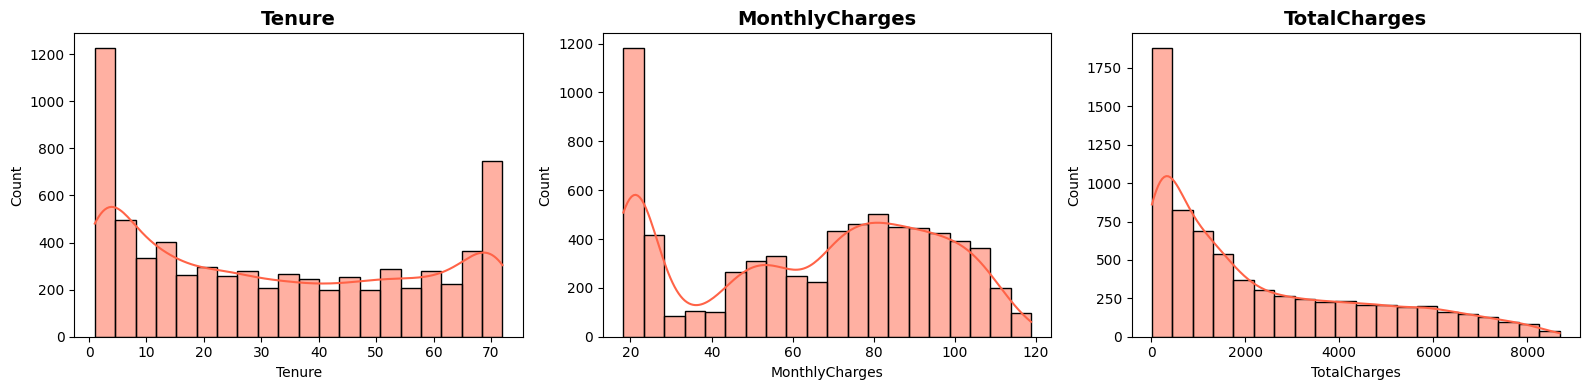

In [14]:
# Visualize numerical distributions to inspect skewness and detect outliers
nums=df.select_dtypes(exclude='object').drop('SeniorCitizen', axis=1)
fig, ax = plt.subplots(1,3, figsize=(16,4))
axes=ax.flatten()
for ax, col in enumerate(nums):
    sns.histplot(df[col], ax=axes[ax], bins=20, kde=True, color='tomato')
    axes[ax].set_title(col, fontweight='bold', fontsize=14)
plt.tight_layout()

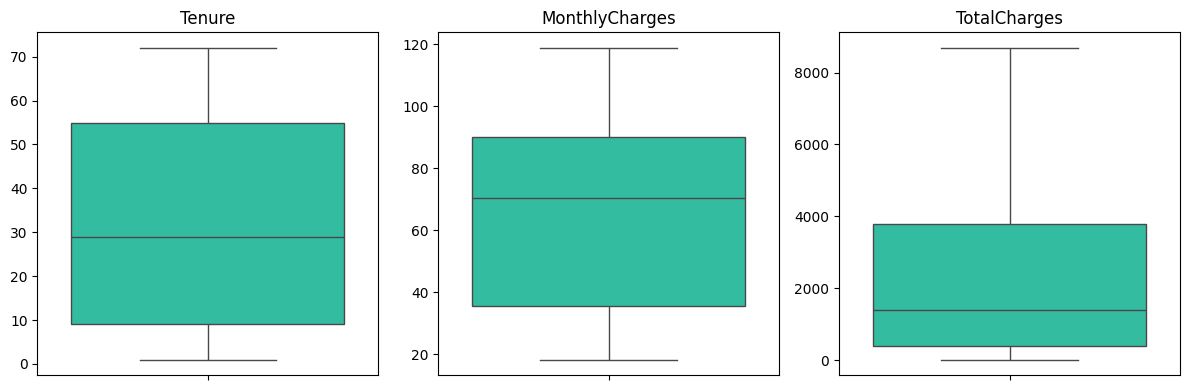

In [15]:
# Visualize numerical columns with boxplots to spot outliers
fig, ax = plt.subplots(1,3, figsize=(12,4))
axes=ax.flatten()
for ax, col in enumerate(nums):
    sns.boxplot(df[col], ax=axes[ax], color="#1dd3ae")
    axes[ax].set_title(col)
    axes[ax].set_ylabel('')
plt.tight_layout()

In [16]:
# Check outliers
for col in nums:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    print(f'Column: {col}\n{len(outliers)} outliers({len(outliers)/len(df)*100:.2f}%)')

Column: Tenure
0 outliers(0.00%)
Column: MonthlyCharges
0 outliers(0.00%)
Column: TotalCharges
0 outliers(0.00%)


In [17]:
# If outlier rate of a column is <=5, clip it to the bounds
# Why 5% ? --> 5% is a heuristic threshold; small number of extreme values
# for col in nums:
#     q1=df[col].quantile(0.25)
#     q3=df[col].quantile(0.75)
#     IQR=q3-q1
#     lower=q1-1.5*IQR
#     upper=q3+1.5*IQR
#     outliers=df[(df[col]<lower) | (df[col]>upper)]
#     if (len(outliers)/len(df)*100) < 5:
#         for i in df.index:
#             if df[col][i]>upper:
#                 df[col][i]=upper
#             elif df[col][i]<lower:
#                 df[col][i]=lower
#     else:
#         print(f'The outlier rate of column ({col}) is bigger than 5%.')
#         df=df[(df[col]>=lower) & (df[col]<=upper)]
#         print(f'Column ({col}) outliers deleted.')

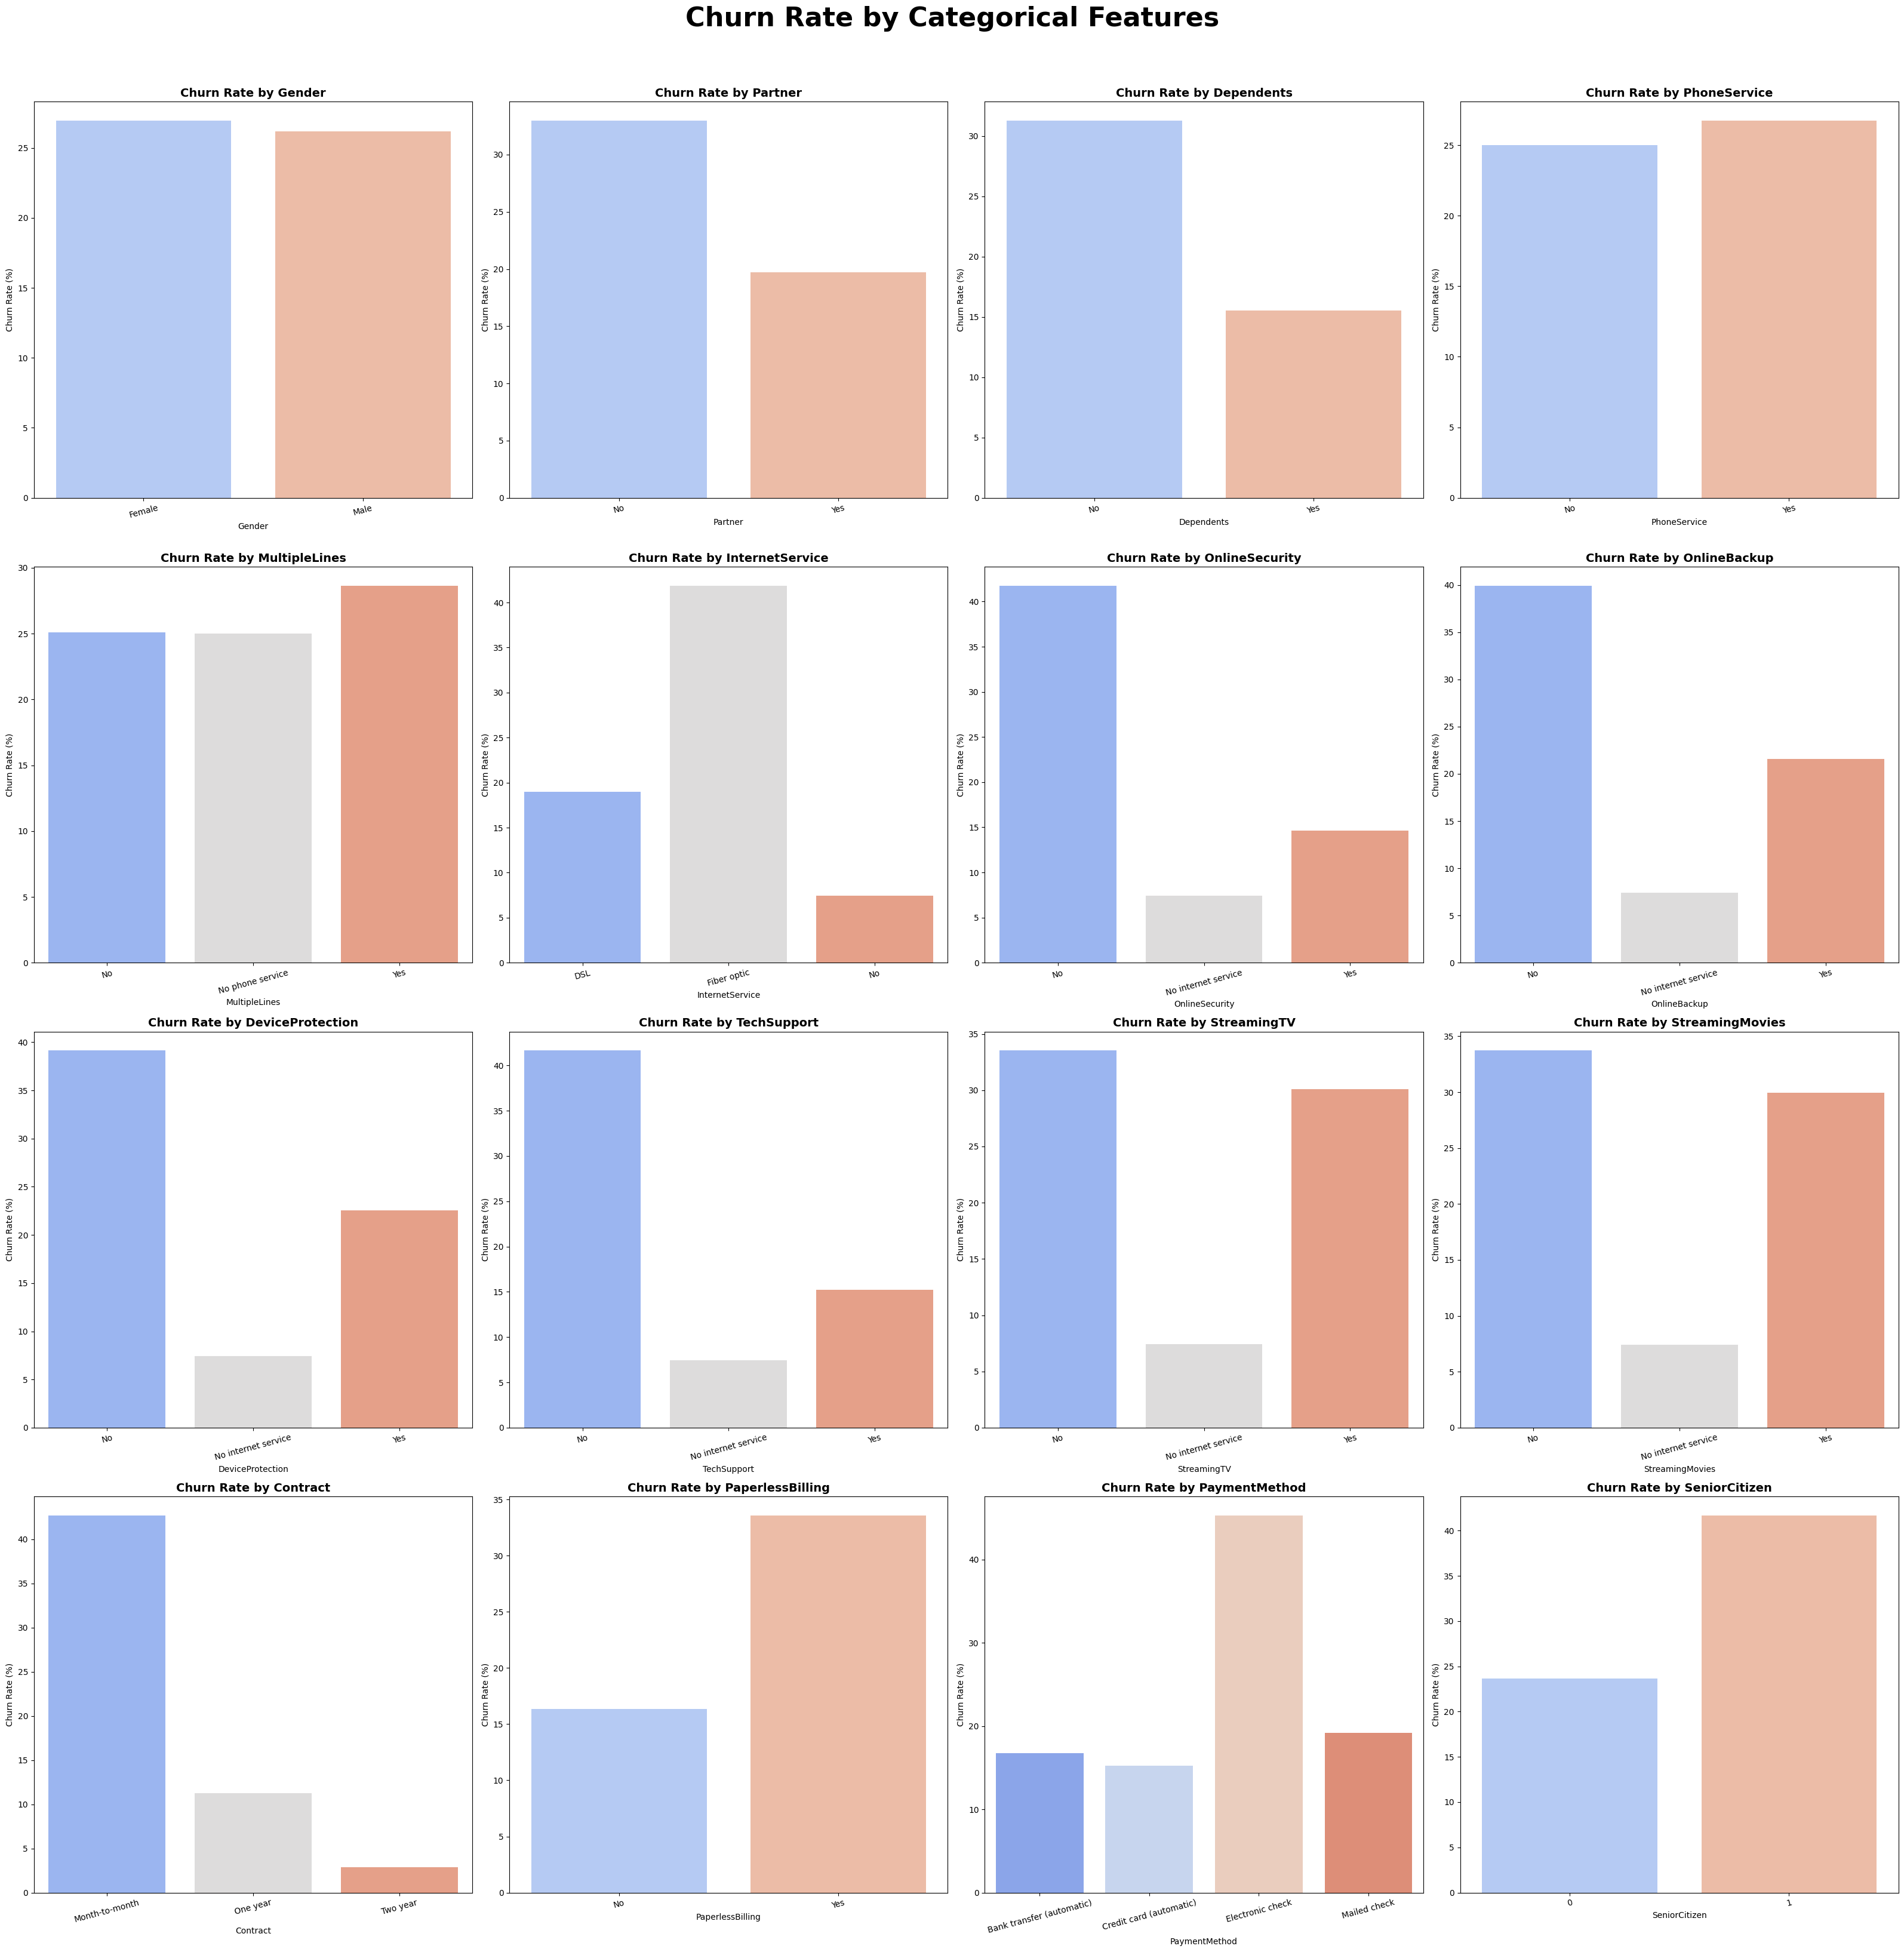

In [18]:
# Churn by categorical features
cat_cols=df.select_dtypes(include='object')
cat_features = [col for col in cat_cols if col !='Churn']+['SeniorCitizen']

fig, axes = plt.subplots(4, 4, figsize=(32, 32))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [feature, 'Churn Rate (%)']

    sns.barplot(
        data=churn_rate,
        x=feature, y='Churn Rate (%)',
        palette='coolwarm', ax=axes[i]
    )
    axes[i].set_title(f'Churn Rate by {feature}', fontweight='bold', fontsize=14)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn Rate by Categorical Features', fontsize=32, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

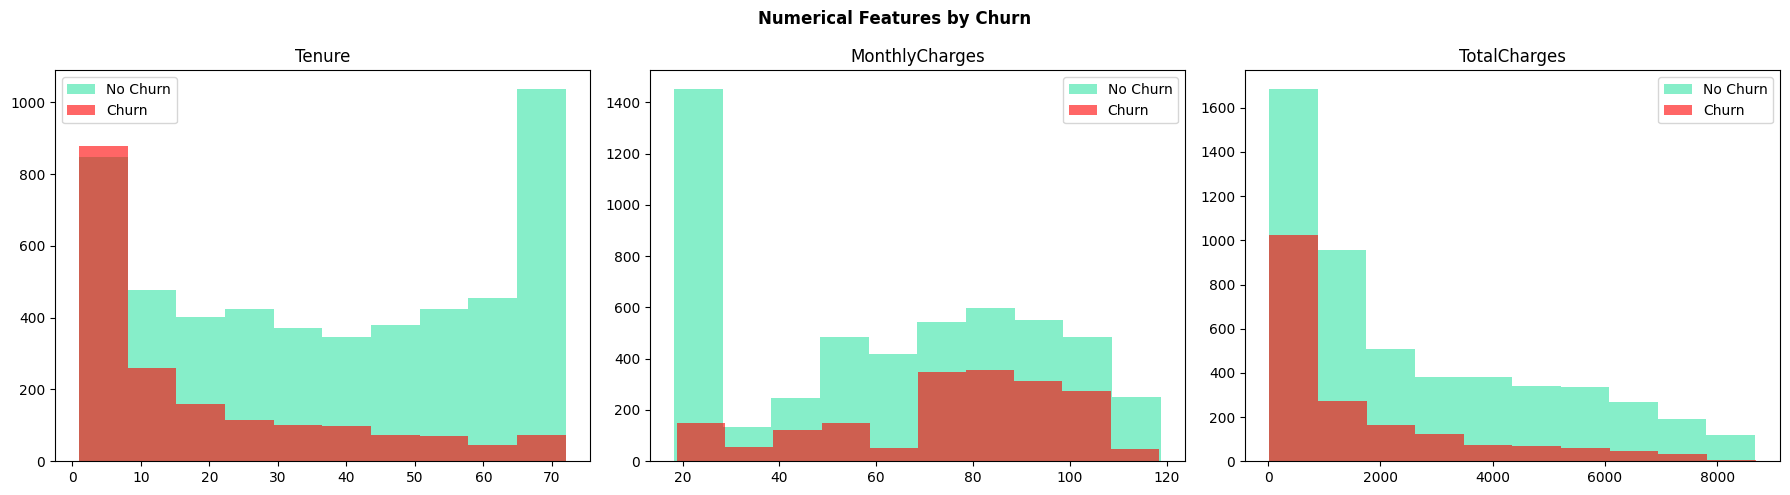

In [19]:
# Numerical Features by Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Tenure', 'MonthlyCharges', 'TotalCharges']):
    df[df['Churn']=='No'][col].hist(ax=ax, alpha=0.6, label='No Churn', color="#35E3A6")
    df[df['Churn']=='Yes'][col].hist(ax=ax, alpha=0.6, label='Churn', color="#ff0000")
    ax.set_title(col)
    ax.grid(False)
    ax.legend()
plt.suptitle('Numerical Features by Churn', fontweight='bold')
plt.tight_layout()
plt.show()

Class rate (%): Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


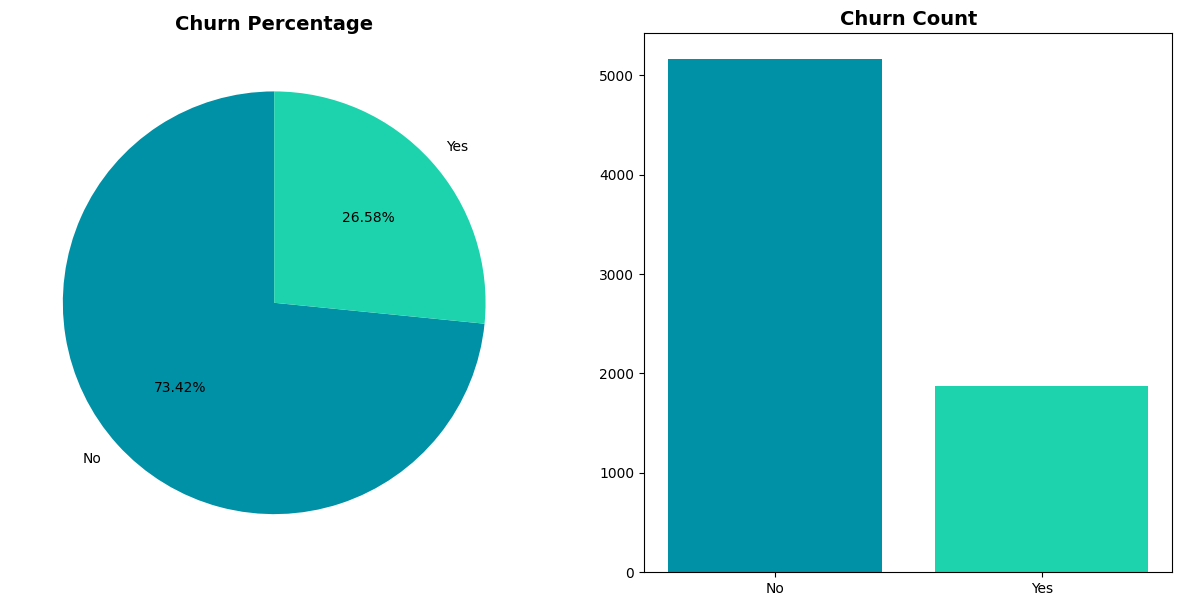

In [20]:
# Churn analysis: percentage (pie) and count (bar) of each class
counts=df['Churn'].value_counts()
print(f'Class rate (%): {(df['Churn'].value_counts(normalize=True)*100).round(2)}')
fig, axes=plt.subplots(1,2, figsize=(15, 7))
axes[0].pie(counts, labels=counts.index, colors=["#0091A7", "#1dd3ae"], autopct='%.2f%%', startangle=90)
axes[0].set_title('Churn Percentage', fontweight='bold', fontsize=14)

axes[1].bar(counts.index, counts.values, color=["#0091A7", "#1dd3ae"])
axes[1].set_title('Churn Count', fontweight='bold', fontsize=14);

## EDA Summary

| Issue | Status | Action |
|-------|--------|--------|
| TotalCharges dtype (object) | Fixed | Converted to float, 11 hidden NaN dropped |
| High cardinality (customerID) | Handled | Dropped — not useful for modelling |
| Null values | Clean | 0 nulls after fix |
| Duplicate rows | Clean | 0 duplicates |
| Constant features | Clean | 0 constant feature found |
| Class imbalance | Exists | 73.5% No / 26.5% Yes — use class_weight='balanced' |
| Outliers | Acceptable | No extreme outliers in numeric columns |

### Key Findings:
- **Contract type** is the strongest churn predictor — Month-to-month customers churn ~3x more
- **Fiber optic** internet users churn more than DSL users
- **New customers** (low tenure) churn significantly more
- **Electronic check** payment users have highest churn rate
- **MonthlyCharges** is higher for churned customers on average

#  Feature Engineering

In [21]:
# Keep df as EDA's backup, work on df_fe
df_fe = df.copy()

In [22]:
# Simplify 'No internet service' / 'No phone service' -> 'No'
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_to_fix:
    df_fe[col] = df_fe[col].replace({'No internet service': 'No', 'No phone service': 'No'})
for col in cols_to_fix:
    print(df_fe[col].value_counts())

MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64
OnlineBackup
No     4607
Yes    2425
Name: count, dtype: int64
DeviceProtection
No     4614
Yes    2418
Name: count, dtype: int64
TechSupport
No     4992
Yes    2040
Name: count, dtype: int64
StreamingTV
No     4329
Yes    2703
Name: count, dtype: int64
StreamingMovies
No     4301
Yes    2731
Name: count, dtype: int64


## Train / Test Split

In [23]:
X = df_fe.drop(columns=['Churn'])
y = df_fe['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (5625, 19)
Test size : (1407, 19)


# Pipeline & model

In [24]:
numeric_cols=X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols=X_train.select_dtypes(include='object').columns.to_list()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

def build_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1,                    # stronger L2 regularization
        penalty='l2',
        class_weight='balanced',
        max_iter=100,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=2,              # limits how deep any single tree can go
        min_samples_leaf=10,      # requires meaningful support before splitting
        max_features='sqrt',      # each tree only sees a random subset of features
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.05,       # slower learning rate spreads influence more evenly
        max_depth=2,              # shallow trees force broader feature usage
        min_samples_leaf=10,
        subsample=0.8,            # random row sampling reduces variance
        max_features='sqrt',      # random feature sampling per split
        random_state=42
    )
}

print('Models and pipelines defined.')

Models and pipelines defined.


In [25]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training: {name} ...')
    pipe = build_pipeline(model)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline' : pipe,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'cv_auc'   : cv_auc,
        'test_auc' : roc_auc_score(y_test, y_prob),
        'f1'       : f1_score(y_test, y_pred, pos_label='Yes'),
        'precision': precision_score(y_test, y_pred, pos_label='Yes'),
        'recall'   : recall_score(y_test, y_pred, pos_label='Yes'),
    }

    print(f'  CV AUC  : {cv_auc.mean():.4f}')
    print(f'  Test AUC: {results[name]["test_auc"]:.4f}')
    print(f'  F1      : {results[name]["f1"]:.4f}')
    print(f'  Precision: {results[name]["precision"]:.4f}')
    print(f'  Recall  : {results[name]["recall"]:.4f}')
    print()

Training: Logistic Regression ...
  CV AUC  : 0.8453
  Test AUC: 0.8358
  F1      : 0.6103
  Precision: 0.4966
  Recall  : 0.7914

Training: Random Forest ...
  CV AUC  : 0.8360
  Test AUC: 0.8282
  F1      : 0.5996
  Precision: 0.4836
  Recall  : 0.7888

Training: Gradient Boosting ...
  CV AUC  : 0.8441
  Test AUC: 0.8336
  F1      : 0.4314
  Precision: 0.6821
  Recall  : 0.3155



## Modelling Summary

**Best model: Logistic Regression** (Test AUC: 0.8358)

### Key Decisions:
- `class_weight='balanced'` used for all models — handles 73.5% / 26.5% class imbalance
- `StratifiedKFold (n_splits=5)` used for cross-validation — preserves class ratio in each fold
- Pipeline used for preprocessing + modelling — prevents data leakage
- Best pipeline saved as `best_pipeline.pkl` for Streamlit deployment

### Why Logistic Regression won:
- Highest Test AUC and best F1 score
- High Recall (0.791) — correctly identifies most churners, which matters most in business context
- Simpler model generalizes better on this dataset size (7,032 rows)

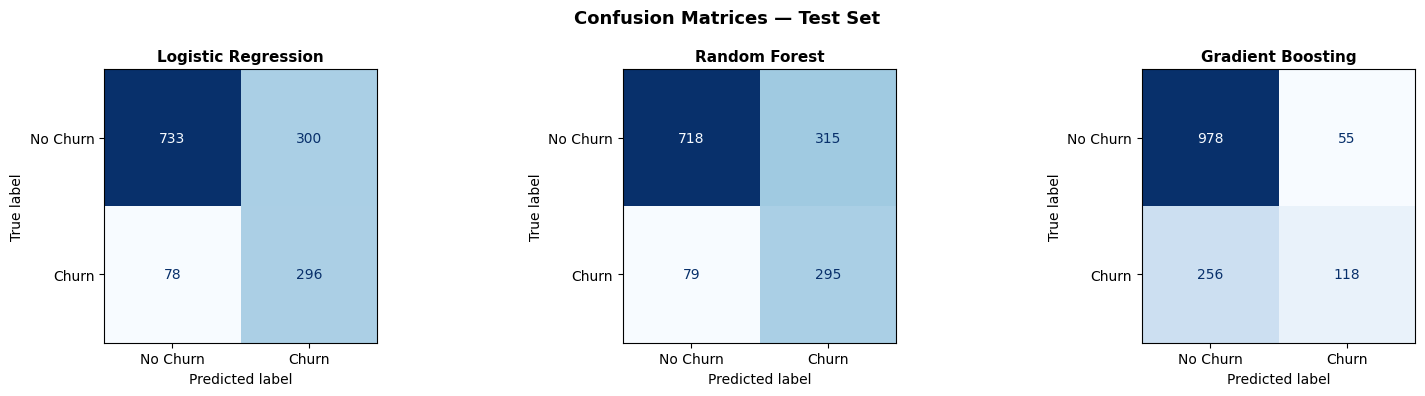

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=['No', 'Yes'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

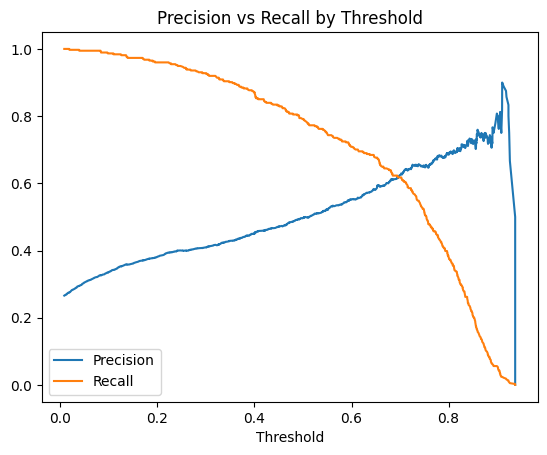

In [27]:
precision, recall, thresholds = precision_recall_curve(
    y_test, results['Logistic Regression']['y_prob'], pos_label='Yes'
)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision vs Recall by Threshold')
plt.show()

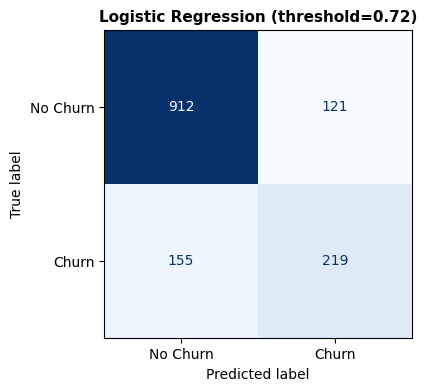

In [28]:
y_pred_new = (results['Logistic Regression']['y_prob'] >= 0.72).astype(int)
y_pred_new = pd.Series(y_pred_new).map({1: 'Yes', 0: 'No'})

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_new, labels=['No', 'Yes'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression (threshold=0.72)', fontsize=11, fontweight='bold')
plt.show()

## Threshold Analysis

Adjusting the decision threshold from 0.5 to 0.72 significantly changes the trade-off:

| Metric | Threshold 0.5 | Threshold 0.72 |
|--------|--------------|----------------|
| False Positives | 300 | 121 |
| False Negatives | 78 | 155 |

**Threshold 0.5** is preferred in telecom context — acquiring a new customer costs ~5x more than retaining one.
Missing a churner (FN) is more costly than offering an unnecessary discount (FP).
Therefore, the default threshold of 0.5 is used for the final model.

# Summary

In [29]:
summary = pd.DataFrame({
    name: {
        'CV AUC Mean' : res['cv_auc'].mean(),
        'CV AUC Std'  : res['cv_auc'].std(),
        'Test AUC'    : res['test_auc'],
        'F1'          : res['f1'],
        'Precision'   : res['precision'],
        'Recall'      : res['recall'],
    }
    for name, res in results.items()
}).T

print(summary.round(4))

                     CV AUC Mean  CV AUC Std  Test AUC      F1  Precision  \
Logistic Regression       0.8453      0.0056    0.8358  0.6103     0.4966   
Random Forest             0.8360      0.0058    0.8282  0.5996     0.4836   
Gradient Boosting         0.8441      0.0073    0.8336  0.4314     0.6821   

                     Recall  
Logistic Regression  0.7914  
Random Forest        0.7888  
Gradient Boosting    0.3155  


# Best model

In [30]:
best_name = max(results, key=lambda x: results[x]['test_auc'])
best_pipe = results[best_name]['pipeline']
print(f'Best model by test AUC: {best_name}  ({results[best_name]["test_auc"]:.4f})')
final_model = best_pipe.named_steps['model']

Best model by test AUC: Logistic Regression  (0.8358)


# Hyperparameter Tuning — Logistic Regression

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

grid = GridSearchCV(
    build_pipeline(LogisticRegression(class_weight='balanced')),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best AUC: {grid.best_score_:.4f}')

Best params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best AUC: 0.8458


In [32]:
best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f'Test AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(classification_report(y_test, y_pred))

Test AUC: 0.8346
              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



## Hyperparameter Tuning Result

GridSearchCV with 5-fold cross-validation was applied to Logistic Regression.

| Metric | Before Tuning | After Tuning |
|--------|--------------|--------------|
| Test AUC | 0.8358 | 0.8346 |
| F1 (Churn) | 0.610 | 0.610 |
| Recall (Churn) | 0.791 | 0.800 |

Tuning did not significantly improve performance — the model had already reached its limit.

# Save best pipeline

In [33]:
import joblib

joblib.dump(best_pipe, 'best_pipeline.pkl')
print(f'Saved: best_pipeline.pkl')

Saved: best_pipeline.pkl


# Select features for streamlit app

In [34]:
final_model = grid.best_estimator_

model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
coefs = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
    "Abs_Coefficient": np.abs(coefs)
})

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

top_features = coef_df.head(10)

print(top_features)

                             Feature  Coefficient  Abs_Coefficient
10           cat__InternetService_No    -2.145160         2.145160
9   cat__InternetService_Fiber optic     2.089910         2.089910
2                num__MonthlyCharges    -1.639853         1.639853
18            cat__Contract_Two year    -1.493705         1.493705
1                        num__Tenure    -1.286576         1.286576
17            cat__Contract_One year    -0.800310         0.800310
15              cat__StreamingTV_Yes     0.765301         0.765301
16          cat__StreamingMovies_Yes     0.751550         0.751550
3                  num__TotalCharges     0.647028         0.647028
8             cat__MultipleLines_Yes     0.528332         0.528332


In [35]:
original_features = list(best_pipe.feature_names_in_)

selected_original = set()

for enc_feat in top_features["Feature"]:

    for orig in original_features:

        if orig in enc_feat:
            selected_original.add(orig)

selected_original = list(selected_original)

print("Selected ORIGINAL features:")
print(selected_original)

print("\nNumber of selected original features:",
      len(selected_original))

Selected ORIGINAL features:
['Tenure', 'TotalCharges', 'InternetService', 'StreamingTV', 'Contract', 'MonthlyCharges', 'MultipleLines', 'StreamingMovies']

Number of selected original features: 8


In [36]:
X_selected = df[selected_original]

print("Shape after selection:")
print(X_selected.shape)

Shape after selection:
(7032, 8)


In [37]:
cat_cols = X_selected.select_dtypes(include="object").columns.tolist()
num_cols = X_selected.select_dtypes(exclude="object").columns.tolist()

preprocessor_small = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline_small = Pipeline([
    ("preprocessor", preprocessor_small),
    ("model", LogisticRegression(
        C=10,
        penalty="l1",
        solver="liblinear",
        max_iter=1000
    ))
])

pipeline_small.fit(X_train[selected_original],y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
import joblib

joblib.dump(
    pipeline_small,
    "best_pipeline_small.pkl"
)

print("New reduced pipeline saved!")

New reduced pipeline saved!
